# Quick Test for `modules/optimization.py`

This notebook generates random PSD matrices `M`, random vectors `w`, and tests:
- `r=2` path (exact 2D sweep),
- `r>2` alternating path (random initialization),
- `r>2` alternating path initialized from the 2D-projected solution,
- brute-force for small `N`,
- convergence-history capture for alternating updates.

In [153]:
import numpy as np
from itertools import product

from modules.optimization import (
    solve_our_optimization,
    compute_V_and_s,
    solve_max_norm_squared_2d,
    solve_max_norm_squared_alternating,
)

def objective(x, M, w):
    x = np.asarray(x).reshape(-1, 1)
    return float(x.T @ M @ x + x.T @ w)

def brute_force_obj(M, w):
    N = M.shape[0]
    best_x = None
    best_val = -np.inf
    for bits in product([-1.0, 1.0], repeat=N):
        x = np.array(bits).reshape(-1, 1)
        val = objective(x, M, w)
        if val > best_val:
            best_val = val
            best_x = x
    return best_val, best_x

def make_psd_M(N, r, rng):
    B = rng.normal(size=(N, r))
    return B @ B.T

def alternating_init_solver(M, w, r, max_iter=100, tol=1e-10, a_init=None, seed=0):
    V, s = compute_V_and_s(M, w, r=r)
    V = np.asarray(V, dtype=float)
    s = np.asarray(s, dtype=float).reshape(-1)
    rr, N = V.shape

    if a_init is not None:
        a = np.asarray(a_init, dtype=float).reshape(-1)
    else:
        rng = np.random.default_rng(seed)
        a = rng.normal(size=rr)

    a_norm = np.linalg.norm(a)
    if a_norm == 0:
        a = np.ones(rr) / np.sqrt(rr)
    else:
        a = a / a_norm

    x = np.ones(N)
    for _ in range(max_iter):
        va = V.T @ a
        sa = float(np.dot(s, a))
        x_new = np.sign(va * sa)
        x_new[x_new == 0] = 1.0

        if np.linalg.norm(x_new - x) <= tol:
            break
        x = x_new

        v_plus_s = V @ x + s
        norm_vs = np.linalg.norm(v_plus_s)
        if norm_vs == 0:
            break
        a = v_plus_s / norm_vs

    return x.reshape(-1, 1), objective(x, M, w), compute_V_and_s(M, w, r=r)[1]

In [154]:
# Test 1: rank-2 exact path + brute-force check (small N)
rng = np.random.default_rng()
N = 12
r_true = 2
M = make_psd_M(N, r_true, rng)
w = rng.normal(size=(N, 1))

x_opt = solve_our_optimization(M, w, r=r_true)
val_alg = objective(x_opt, M, w)
val_brute, x_brute = brute_force_obj(M, w)

print('N:', N, 'r:', r_true)
print('solver value (r=2):', val_alg)
print('brute value      :', val_brute)
print('value gap        :', val_alg - val_brute)
print('matches optimum?  :', np.allclose(x_opt, x_brute) or np.allclose(x_opt, -x_brute))

N: 12 r: 2
solver value (r=2): 221.30871991637056
brute value      : 221.30871991637056
value gap        : 0.0
matches optimum?  : True


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_24318/1637200139.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x.T @ M @ x + x.T @ w)


In [155]:
# Test 2: rank>2 alternating path (monotone update, heuristic path)
rng = np.random.default_rng()
N = 100
r_true = 6
M = make_psd_M(N, r_true, rng)
w = rng.normal(size=(N, 1))

# directly test new branch
x_alt = solve_our_optimization(M, w, r=r_true)
val_alt = objective(x_alt, M, w)

# check against a random binary baseline
x_rand = np.where(rng.uniform(size=(N, 1)) > 0.5, 1.0, -1.0)
val_rand = objective(x_rand, M, w)

print('N:', N, 'r:', r_true)
print('alternating value:', val_alt)
print('random baseline  :', val_rand)
print('improvement     :', val_alt - val_rand)

N: 100 r: 6
alternating value: 6103.722691974512
random baseline  : 716.9080769266808
improvement     : 5386.814615047831


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_24318/1637200139.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x.T @ M @ x + x.T @ w)


In [156]:
M

array([[ 8.66658626,  0.93930698,  0.59855755, ..., -2.02790919,
         1.16287283, -7.46681711],
       [ 0.93930698,  7.45639245, -0.29569351, ..., -3.96271081,
        -2.84221521,  2.75079711],
       [ 0.59855755, -0.29569351, 14.47746151, ...,  0.54200194,
        -3.34179086, -4.5012038 ],
       ...,
       [-2.02790919, -3.96271081,  0.54200194, ...,  5.28679162,
         1.30050761, -1.36185284],
       [ 1.16287283, -2.84221521, -3.34179086, ...,  1.30050761,
         4.18619561,  1.60515649],
       [-7.46681711,  2.75079711, -4.5012038 , ..., -1.36185284,
         1.60515649, 15.08606705]], shape=(100, 100))

In [157]:
# Test 3: repeat a few random trials to see stability
trials = 5
N = 60
r_for_solver = 4

vals = []
for t in range(trials):
    rng = np.random.default_rng()
    M = make_psd_M(N, r_for_solver, rng)
    w = rng.normal(size=(N, 1))
    x = solve_our_optimization(M, w, r=r_for_solver)
    vals.append(objective(x, M, w))

print('trial objective values (r>2 path):')
print(vals)
print('mean value:', np.mean(vals))
print('std value :', np.std(vals))

trial objective values (r>2 path):
[2522.950273344123, 3015.8763757413744, 3161.977013955047, 1947.3570388344979, 2492.4181391585735]
mean value: 2628.1157682067233
std value : 430.87636136670704


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_24318/1637200139.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x.T @ M @ x + x.T @ w)


In [158]:
# Test 4: alternating initialization comparison against brute-force (small N)
rng = np.random.default_rng()
N = 10
r_true = 4
M = make_psd_M(N, r_true, rng)
w = rng.normal(size=(N, 1))

# alternating with random initialization
x_randinit, val_randinit, _ = alternating_init_solver(M, w, r=r_true, max_iter=200, seed=int(rng.integers(0, 10**9)))

# alternating initialized from projected r=2 solution
V2, s2 = compute_V_and_s(M, w, r=2)
x_2d = solve_max_norm_squared_2d(V2, s2)
V_full, s_full = compute_V_and_s(M, w, r=r_true)
a_from_2d = (V_full @ x_2d + s_full.reshape(-1, 1)).reshape(-1)
x_proj_init, val_proj_init, _ = alternating_init_solver(M, w, r=r_true, max_iter=200, a_init=a_from_2d)

# brute force optimum
val_brute, x_brute = brute_force_obj(M, w)

print('N:', N, 'r:', r_true)
print('alternating (random init):', val_randinit)
print('alternating (proj r=2 init):', val_proj_init)
print('brute force value       :', val_brute)
print('random init gap         :', val_randinit - val_brute)
print('proj r=2 init gap       :', val_proj_init - val_brute)
print('random init matches opt? :', np.allclose(x_randinit, x_brute) or np.allclose(x_randinit, -x_brute))
print('proj r=2 init matches :', np.allclose(x_proj_init, x_brute) or np.allclose(x_proj_init, -x_brute))

N: 10 r: 4
alternating (random init): 87.00460216080421
alternating (proj r=2 init): 183.95431542461048
brute force value       : 183.95431542461048
random init gap         : -96.94971326380627
proj r=2 init gap       : 0.0
random init matches opt? : False
proj r=2 init matches : True


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_24318/1637200139.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x.T @ M @ x + x.T @ w)


In [159]:
# Test 5: near-equal eigenvalue case (harder spectrum)
rng = np.random.default_rng()
N = 8
r_true = 4
eig_center = 1.0
eps = 1e-4
# construct an orthogonal matrix
Q, _ = np.linalg.qr(rng.normal(size=(N, N)))
# eigenvalues are almost equal (small spread around eig_center)
nearly_equal_eigs = eig_center + eps * (np.linspace(-1, 1, N) + 1e-2 * rng.normal(size=N))
M = Q @ np.diag(nearly_equal_eigs) @ Q.T
M = (M + M.T) / 2  # numerical symmetrization
w = rng.normal(size=(N, 1))

# alternating with random initialization (r > 2)
x_randinit_ne, val_randinit_ne, _ = alternating_init_solver(M, w, r=r_true, max_iter=300, seed=7)

# alternating initialized from projected r=2 solution
V2_ne, s2_ne = compute_V_and_s(M, w, r=2)
x_2d_ne = solve_max_norm_squared_2d(V2_ne, s2_ne)
V_full_ne, s_full_ne = compute_V_and_s(M, w, r=r_true)
a_from_2d_ne = (V_full_ne @ x_2d_ne + s_full_ne.reshape(-1, 1)).reshape(-1)
x_proj_init_ne, val_proj_init_ne, _ = alternating_init_solver(M, w, r=r_true, max_iter=300, a_init=a_from_2d_ne)

# reference: r=2 branch on the same M for comparison (not exact when r>2)
x_2d_branch = solve_our_optimization(M, w, r=2)
val_2d_branch = objective(x_2d_branch, M, w)

# brute-force optimum
val_brute_ne, x_brute_ne = brute_force_obj(M, w)

print('Eigenvalues (first/last):', nearly_equal_eigs[0], nearly_equal_eigs[-1])
print('max-min eigen spread:', np.max(nearly_equal_eigs) - np.min(nearly_equal_eigs))
print('alternating random init value:', val_randinit_ne)
print('alternating proj r=2 init value:', val_proj_init_ne)
print('2D branch value (r=2):', val_2d_branch)
print('brute force value:', val_brute_ne)
print('gaps vs brute: rand-init, proj-init, 2D=', val_randinit_ne - val_brute_ne, val_proj_init_ne - val_brute_ne, val_2d_branch - val_brute_ne)
print('rand-init matches optimum:', np.allclose(x_randinit_ne, x_brute_ne) or np.allclose(x_randinit_ne, -x_brute_ne))
print('proj-init matches optimum:', np.allclose(x_proj_init_ne, x_brute_ne) or np.allclose(x_proj_init_ne, -x_brute_ne))

Eigenvalues (first/last): 0.9999005814368127 1.0001004732519192
max-min eigen spread: 0.0001998918151064899
alternating random init value: 7.014353578040671
alternating proj r=2 init value: 8.237684067675232
2D branch value (r=2): 8.237684067675232
brute force value: 15.842797827904239
gaps vs brute: rand-init, proj-init, 2D= -8.828444249863567 -7.605113760229006 -7.605113760229006
rand-init matches optimum: False
proj-init matches optimum: False


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_24318/1637200139.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x.T @ M @ x + x.T @ w)


iterations: 7
x snapshot count: 8
a snapshot count: 8
final delta_x: 0.0
norm path min/max: 7.420948423622296 41.92855535741182
best historical objective: 1750.98676950186
best iteration: 6
final objective: 1750.98676950186
objective non-decreasing over iterations: True


/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_24318/1637200139.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x.T @ M @ x + x.T @ w)


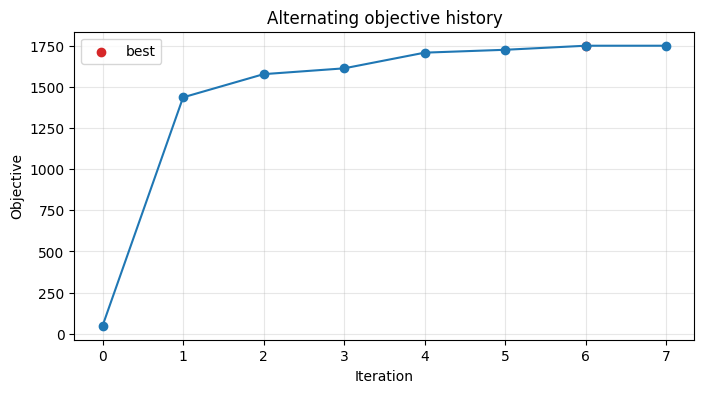

In [160]:
# Test 6: alternating solver convergence history
rng = np.random.default_rng()
N = 50
r_true = 5
M = make_psd_M(N, r_true, rng)
w = rng.normal(size=(N, 1))
V_test, s_test = compute_V_and_s(M, w, r=r_true)

x_hist_test, history_test = solve_max_norm_squared_alternating(
    V_test,
    s_test,
    max_iter=60,
    return_history=True
)

# objective at every x snapshot
hist_obj = [objective(x_vec, M, w) for x_vec in history_test["x"]]
best_iter = int(np.argmax(hist_obj))
is_non_decreasing = all(curr + 1e-12 >= prev for prev, curr in zip(hist_obj[:-1], hist_obj[1:]))

print("iterations:", history_test["iterations"])
print("x snapshot count:", len(history_test["x"]))
print("a snapshot count:", len(history_test["a"]))
print("final delta_x:", float(history_test["delta_x"][-1]) if history_test["delta_x"].size else 0.0)
print("norm path min/max:", float(np.min(history_test["norm"])), float(np.max(history_test["norm"])) )
print("best historical objective:", float(np.max(hist_obj)))
print("best iteration:", best_iter)
print("final objective:", float(hist_obj[-1]))
print("objective non-decreasing over iterations:", is_non_decreasing)

try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    plt.plot(hist_obj, marker="o")
    plt.scatter([best_iter], [hist_obj[best_iter]], color="tab:red", label="best")
    plt.title("Alternating objective history")
    plt.xlabel("Iteration")
    plt.ylabel("Objective")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
except Exception as _:
    print("Plot skipped: matplotlib is unavailable in this environment.")
    print("Objective history values:")
    print(hist_obj)
